In [ ]:
from google.colab import files
files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:03<00:00, 33.8MB/s]



In [ ]:
!unzip cifake-real-and-ai-generated-synthetic-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/REAL/4500 (10).jpg  
  inflating: train/REAL/4500 (2).jpg  
  inflating: train/REAL/4500 (3).jpg  
  inflating: train/REAL/4500 (4).jpg  
  inflating: train/REAL/4500 (5).jpg  
  inflating: train/REAL/4500 (6).jpg  
  inflating: train/REAL/4500 (7).jpg  
  inflating: train/REAL/4500 (8).jpg  
  inflating: train/REAL/4500 (9).jpg  
  inflating: train/REAL/4500.jpg     
  inflating: train/REAL/4501 (10).jpg  
  inflating: train/REAL/4501 (2).jpg  
  inflating: train/REAL/4501 (3).jpg  
  inflating: train/REAL/4501 (4).jpg  
  inflating: train/REAL/4501 (5).jpg  
  inflating: train/REAL/4501 (6).jpg  
  inflating: train/REAL/4501 (7).jpg  
  inflating: train/REAL/4501 (8).jpg  
  inflating: train/REAL/4501 (9).jpg  
  inflating: train/REAL/4501.jpg     
  inflating: train/REAL/4502 (10).jpg  
  inflating: train/REAL/4502 (2).jpg  
  inflating: train/REAL/4502 (3).jpg  
  inflating: train/REAL/4502 (4).jpg  
  inflating:

In [ ]:
!ls train
!ls test

FAKE  REAL
FAKE  REAL


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Configuration
TRAIN_DIR = "/content/train"
TEST_DIR = "/content/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE_1 = 10
EPOCHS_STAGE_2 = 8
MODEL_SAVE_PATH = "/content/efficientnet_cifake.keras"

# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Train class indices:", train_generator.class_indices)
print("Validation class indices:", val_generator.class_indices)
print("Test class indices:", test_generator.class_indices)

# Build EfficientNetB0 Model
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(224, 224, 3))
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_loss", save_best_only=True, verbose=1)
]

#Train top layers
history_stage_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE_1,
    callbacks=callbacks
)

#Fine-tune top layers of EfficientNet
base_model.trainable = True

# Freeze most layers, unfreeze last ~30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_stage_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE_2,
    callbacks=callbacks
)


Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Train class indices: {'FAKE': 0, 'REAL': 1}
Validation class indices: {'FAKE': 0, 'REAL': 1}
Test class indices: {'FAKE': 0, 'REAL': 1}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8285 - loss: 0.3805
Epoch 1: val_loss improved from None to 0.24378, saving model to /content/efficientnet_cifake.keras

Epoch 1: finished saving model to /content/efficientnet_cifake.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1555s 609ms/step - accuracy: 0.8575 - loss: 0.3313 - val_accuracy: 0.9005 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8804 - loss: 0.2837
Epoch 2: val_loss improved from 0.24378 to 0.23005, saving model to /content/efficientnet_cifake.keras

Epoch 2: finished saving model to /content/efficientnet_cifake.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1498s 599ms/step - accuracy: 0.8841 - loss: 0.2781 - val_accuracy: 0.9076 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8920 - loss: 0.2624
Epoch 3: val_loss improved from 0.23005 to 0.22481, saving model to /content/efficientnet_c

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8372 - loss: 0.4651
Test Loss: 0.4651
Test Accuracy: 83.72%


625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step


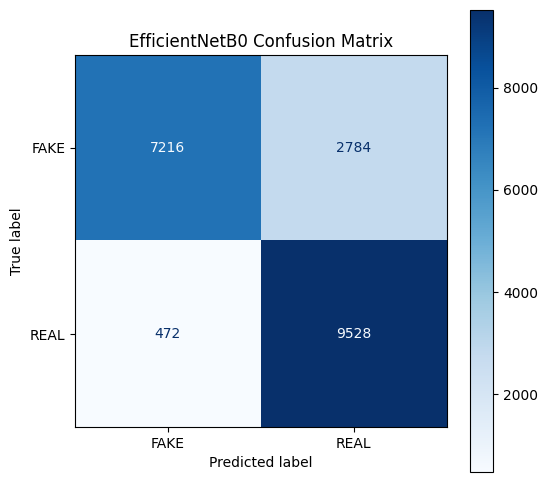


Classification Report:

              precision    recall  f1-score   support

        FAKE       0.94      0.72      0.82     10000
        REAL       0.77      0.95      0.85     10000

    accuracy                           0.84     20000
   macro avg       0.86      0.84      0.83     20000
weighted avg       0.86      0.84      0.83     20000



In [ ]:
# Predictions + Confusion Matrix
test_generator.reset()
y_true = test_generator.classes
y_prob = model.predict(test_generator, verbose=1)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_true, y_pred)
labels = list(test_generator.class_indices.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))

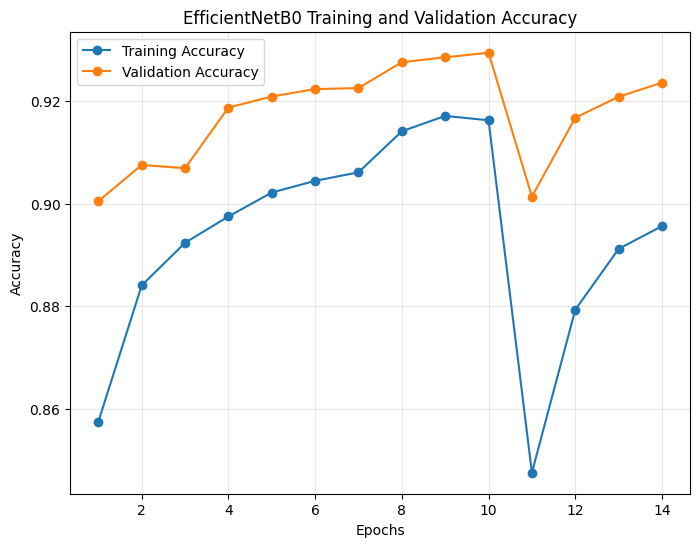

In [ ]:
# Plot Accuracy
def combine_history(hist1, hist2, key):
    return hist1.history.get(key, []) + hist2.history.get(key, [])

train_acc = combine_history(history_stage_1, history_stage_2, "accuracy")
val_acc = combine_history(history_stage_1, history_stage_2, "val_accuracy")

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_acc) + 1), train_acc, marker="o", label="Training Accuracy")
plt.plot(range(1, len(val_acc) + 1), val_acc, marker="o", label="Validation Accuracy")
plt.title("EfficientNetB0 Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Save final model
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: /content/efficientnet_cifake.keras


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

model = load_model("/content/efficientnet_cifake.keras")

def predict_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img).astype("float32")
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)[0][0]
    print(f"Raw prediction score: {prediction:.6f}")

    return "Real" if prediction > 0.5 else "AI-Generated"

image_path = "/content/drive/MyDrive/IMG_20260321_202224.jpg"
result = predict_image(image_path)
print("Prediction:", result)

Raw prediction score: 0.677291
Prediction: Real
